### Научно-исследовательская работа по дисциплине _Технологии Машинного Обучения_

**Тема: Анализ факторов, влияющих на популярность исторических личностей, с применением методов машинного обучения**

#### Исполнитель: **Мефодьев Илья Николаевич, группа ИУ5Ц-82Б**

Цель научно-исследовательской работы: решение задачи машинного обучения на основе материалов дисциплины. Выполняется студентом единолично.

Схема типового исследования, проводимого студентом в рамках курсовой работы, содержит выполнение следующих шагов:

1. Поиск и выбор набора данных для построения моделей машинного обучения. На основе выбранного набора данных студент должен построить модели машинного обучения для решения или задачи классификации, или задачи регрессии.

2. Проведение разведочного анализа данных. Построение графиков, необходимых для понимания структуры данных. Анализ и заполнение пропусков в данных.
    
3. Выбор признаков, подходящих для построения моделей. Кодирование категориальных признаков. Масштабирование данных. Формирование вспомогательных признаков, улучшающих качество моделей.
    
4. Проведение корреляционного анализа данных. Формирование промежуточных выводов о возможности построения моделей машинного обучения. В зависимости от набора данных, порядок выполнения пунктов 2, 3, 4 может быть изменен.
    
5. Выбор метрик для последующей оценки качества моделей. Необходимо выбрать не менее трех метрик и обосновать выбор.
    
6. Выбор наиболее подходящих моделей для решения задачи классификации или регрессии. Необходимо использовать не менее пяти моделей, две из которых должны быть ансамблевыми.
    
7. Формирование обучающей и тестовой выборок на основе исходного набора данных.
    
8. Построение базового решения (baseline) для выбранных моделей без подбора гиперпараметров. Производится обучение моделей на основе обучающей выборки и оценка качества моделей на основе тестовой выборки.
    
9. Подбор гиперпараметров для выбранных моделей. Рекомендуется использовать методы кросс-валидации. В зависимости от используемой библиотеки можно применять функцию GridSearchCV, использовать перебор параметров в цикле, или использовать другие методы.
    
10. Повторение пункта 8 для найденных оптимальных значений гиперпараметров. Сравнение качества полученных моделей с качеством baseline-моделей.
    
11. Формирование выводов о качестве построенных моделей на основе выбранных метрик. Результаты сравнения качества рекомендуется отобразить в виде графиков и сделать выводы в форме текстового описания. Рекомендуется построение графиков обучения и валидации, влияния значений гиперпарметров на качество моделей и т.д.
    
12. Создание веб-приложение для демонстрации хотя бы одной модели машинного обучения. У пользователя должна быть возможность изменения хотя бы одного гиперпараметра модели, при изменении гиперпараметра модель должна перестраиваться в веб-интерфейсе. 

В качестве рабочего датасета будет использован _Pantheon Project: Historical Popularity Index_

Данные Pantheon измеряют глобальную популярность исторических персонажей с помощью двух показателей. Более простой изsd двух показателей, которые обозначаются как L, — это количество различных языковых версий Википедии, содержащих статью об историческом персонаже. Более сложный показатель, который называн Индексом исторической популярности (HPI), корректирует L, добавляя информацию о возрасте исторического персонажа, концентрации просмотров страниц на разных языках, коэффициенте вариации просмотров страниц и количестве просмотров страниц на языках, отличных от английского.

Все данные были проверены вручную и ограничиваются семнадцатью столбцами:

1. **article_id** - Уникальный ID статьи в английской Википедии 

2. **full_name** - Имя исторической личности (на английском)

3. **sex** - Пол: Male / Female

4. **birth_year** - год рождения

5. **city** - Город, в которой эта фигура осуществляла свою основную деятельность.

6. **state** - Штат (если применимо), в котором данная фигура проявляла основную активность.

7. **country** - Страна, в которой эта фигура осуществляла свою основную деятельность.

8. **continent** - Континент, на котором эта фигура проявляла свою основную активность.

9. **latitude** - Центральная широта города, штата и т. д., в котором действовала данная фигура.

10. **longitude** - Центральная долгота города, штата и т. д., в котором действовала данная фигура.

11. **occupation** - Конкретная профессия исторической личности. Например, physicist.

12. **industry** - Отрасль (или тематическая область), в которой данный человек сосредоточил свою работу. Например, philosophy.

13. **domain** - Общая область деятельности, в которой известна данная личность. Например, гуманитарные науки.

14. **article_languages** - В скольких из различных языков Википедии есть статья об этом рисунке?

15. **page_views** - Примерное общее количество просмотров этой страницы во всех Википедиях.

16. **average_views** - Приблизительное среднее количество просмотров страницы ист. фигуры в каждой статье Википедии.

17. **historical_popularity_index** - Индексный показатель, приблизительно отражающий популярность статьи об этой личности и, следовательно, степень её известности.



Первым делом необходимо загрузить датасет и посмотреть его примерное содержимое

In [1]:
# добавим необходимые модули
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.model_selection import GridSearchCV
import warnings

In [2]:
pantheon_origin = pd.read_csv("./database.csv")

pantheon_origin.head(30)

,article_id,full_name,sex,birth_year,city,state,country,continent,latitude,longitude,occupation,industry,domain,article_languages,page_views,average_views,historical_popularity_index
0,308,Aristotle,Male,-384,Stageira,NaN,Greece,Europe,40.33333,23.50000,Philosopher,Philosophy,Humanities,152,56355172,370758,31.9938
1,22954,Plato,Male,-427,Athens,NaN,Greece,Europe,37.96667,23.71667,Philosopher,Philosophy,Humanities,142,46812003,329662,31.9888
2,1095706,Jesus Christ,Male,-4,Judea,NaN,Israel,Asia,32.50000,34.90000,Religious Figure,Religion,Institutions,214,60299092,281771,31.8981
3,25664190,Socrates,Male,-469,Athens,NaN,Greece,Europe,37.96667,23.71667,Philosopher,Philosophy,Humanities,137,40307143,294213,31.6521
4,783,Alexander the Great,Male,-356,Pella,NaN,Greece,Europe,40.80000,22.51667,Military Personnel,Military,Institutions,138,48358148,350421,31.5840
5,18079,Leonardo da Vinci,Male,1452,Vinci,NaN,Italy,Europe,43.78333,10.91667,Inventor,Invention,Science & Technology,174,88931135,511098,31.4644
6,5823,Confucius,Male,-551,Qufu,NaN,China,Asia,NaN,NaN,Philosopher,Philosophy,Humanities,192,22363652,116477,31.3705
7,15924,Julius Caesar,Male,-100,Rome,NaN,Italy,Europe,41.90000,12.50000,Politician,Government,Institutions,128,43088745,336631,31.1161
8,13633,Homer,Male,-800,Smyrna,NaN,Turkey,Europe,38.41861,27.13917,Writer,Language,Humanities,141,20839405,147797,31.1087
9,23275,Pythagoras,Male,-570,Samos Island,NaN,Greece,Europe,37.75000,26.83333,Philosopher,Philosophy,Humanities,114,26168219,229546,31.0691


В целом картина ясная. Но нужно перед работой с нейронными сетями предобработать все данные.

Сперва проверим типы столбцов

In [3]:
print(pantheon_origin.dtypes)

article_id                       int64
full_name                          str
sex                                str
birth_year                         str
city                               str
state                              str
country                            str
continent                          str
latitude                       float64
longitude                      float64
occupation                         str
industry                           str
domain                             str
article_languages                int64
page_views                       int64
average_views                    int64
historical_popularity_index    float64
dtype: object


Видно, что столбец birth_year, явно с числовыми данными, нужно привести к соответствующему виду.

In [4]:
# приводим столбцы к числовому виду

# Копируем исходный датасет, чтобы не портить оригинал
df = pantheon_origin.copy()

# Список столбцов, которые должны быть числами
numeric_cols = ['birth_year']

# Применяем преобразование ко всем сразу
df[numeric_cols] = df[numeric_cols].apply(lambda col: pd.to_numeric(col, errors='coerce'))

print(df.dtypes)

article_id                       int64
full_name                          str
sex                                str
birth_year                     float64
city                               str
state                              str
country                            str
continent                          str
latitude                       float64
longitude                      float64
occupation                         str
industry                           str
domain                             str
article_languages                int64
page_views                       int64
average_views                    int64
historical_popularity_index    float64
dtype: object


Посмотрим на статистику по пропускам

In [5]:
# Общая информация о пропусках
print("Пропуски по столбцам")
print(pantheon_origin.isnull().sum())
print(f"\nВсего строк: {len(pantheon_origin)}")

# Корреляция пропусков: если нет latitude, часто нет и longitude?
print("\nСовместные пропуски")
print(pantheon_origin[['latitude', 'longitude']].isnull().sum(axis=1).value_counts())

Пропуски по столбцам
article_id                        0
full_name                         0
sex                               0
birth_year                        0
city                              0
state                          9169
country                          33
continent                        30
latitude                       1047
longitude                      1047
occupation                        0
industry                          0
domain                            0
article_languages                 0
page_views                        0
average_views                     0
historical_popularity_index       0
dtype: int64

Всего строк: 11341

Совместные пропуски
0    10294
2     1047
Name: count, dtype: int64


Удалим state столбец полностью, поскольку он, скорее всего, относится лишь к деятелям из США. Удалим пропуски в country и continent. а latitude и longtitude заполним медианой по континенту.

In [6]:
# Удаляем столбец state (слишком много пропусков)
df = df.drop(columns=['state'])

# Удаляем строки с пропусками в country или continent (по 30 строк)
df = df.dropna(subset=['country', 'continent'])

# Заполняем пропуски медианой по континенту
df['latitude']  = df.groupby('continent')['latitude'].transform(lambda x: x.fillna(x.median()))
df['longitude'] = df.groupby('continent')['longitude'].transform(lambda x: x.fillna(x.median()))

# Fallback: если у какого-то континента ВСЕ координаты были NaN, заполняем общей медианой
df['latitude']  = df['latitude'].fillna(df['latitude'].median())
df['longitude'] = df['longitude'].fillna(df['longitude'].median())

# Проверяем
print("Осталось пропусков:")
print(df[['latitude', 'longitude']].isnull().sum())

# Проверяем результат
print("Пропуски после обработки")
print(df.isnull().sum())
print(f"\nОсталось строк: {len(df)} (было: {len(pantheon_origin)})")

Осталось пропусков:
latitude     0
longitude    0
dtype: int64
Пропуски после обработки
article_id                     0
full_name                      0
sex                            0
birth_year                     4
city                           0
country                        0
continent                      0
latitude                       0
longitude                      0
occupation                     0
industry                       0
domain                         0
article_languages              0
page_views                     0
average_views                  0
historical_popularity_index    0
dtype: int64

Осталось строк: 11278 (было: 11341)


На всякий случай проверим статистику по широте и долготе

           latitude     longitude
count  11278.000000  11278.000000
mean      40.053430     -5.751593
std       18.182855     53.939841
min      -51.633330   -175.200560
25%       37.966670    -34.893195
50%       43.716670      5.415000
75%       50.325500     16.916670
max       70.073330    178.017780

Пропуски: latitude=0, longitude=0


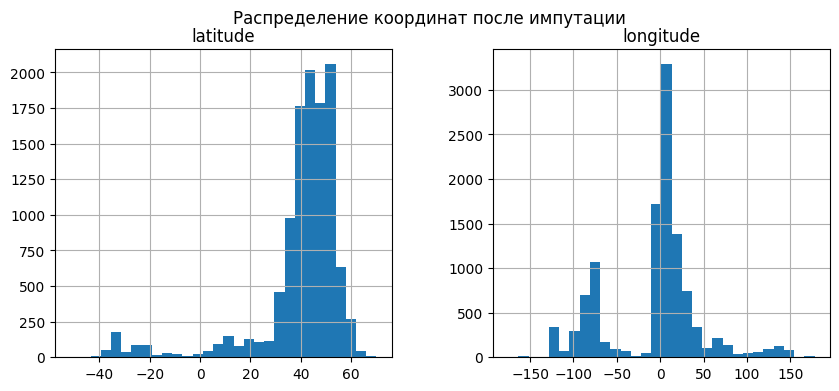

In [7]:
# Статистика по столбцам после обработки
print(df[['latitude', 'longitude']].describe())
print(f"\nПропуски: latitude={df['latitude'].isnull().sum()}, longitude={df['longitude'].isnull().sum()}")

# гистограмма распределения 
df[['latitude', 'longitude']].hist(bins=30, figsize=(10,4))
plt.suptitle('Распределение координат после импутации')
plt.show()

Ради интереса посмотрим, кто был в удалённых строках

In [8]:
dropped = pantheon_origin[pantheon_origin['country'].isnull() | pantheon_origin['continent'].isnull()]
print(dropped[['full_name', 'occupation', 'birth_year']].head(20))

                    full_name          occupation birth_year
13                    Abraham    Religious Figure      -1800
34                     Euclid       Mathematician       -325
54                      Aesop              Writer       -620
105            Judas Iscariot    Religious Figure         -1
165                     Khufu          Politician      -2600
250   Marcus Vitruvius Pollio           Architect        -80
272          Romulus Augustus    Religious Figure        460
300                 Lucretius         Philosopher        -99
332              Thutmose III          Politician      -1481
340           Ptolemy I Soter  Military Personnel       -367
354                 Vitellius          Politician         24
636              Julius Nepos          Politician        430
704     Cambyses II of Persia          Politician       -600
1112            Saint Stephen    Religious Figure          1
1150                    Livia           Companion        -58
1157              Jackie

Удалим оставшиеся ненужные столбцы

In [9]:
df = df.drop(columns=['article_id', 'full_name', 'city'])

Создадим новые признаки и проведём кодирование:

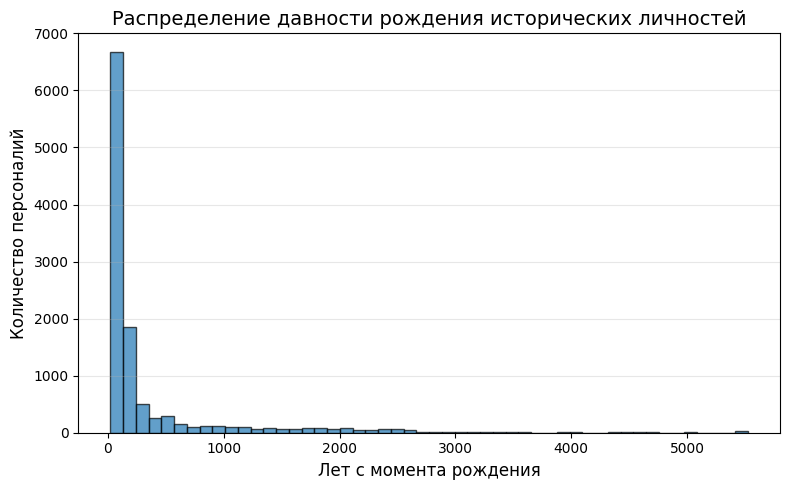

In [ ]:
# разделим деятелей по эпохам (потом решил переделать)
# df['era'] = pd.cut(df['birth_year'], 
#                    bins=[-4000, -500, 500, 1450, 2026], 
#                    labels=['Ancient', 'Classical', 'Medieval', 'Modern'])

# Дабы переделать год на числовой признак, сделаю вычитание из текущего (т.е. 2026 года)
# "давность" (сколько лет прошло с рождения)
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['years_since_birth'] = 2026 - df['birth_year']

# т.к. в birth_year было 4 пропуска, то надо их удалить
df = df.dropna(subset=['years_since_birth'])

# посмотрим на получившуюся статистику по рождениям
plt.figure(figsize=(8, 5))
plt.hist(df['years_since_birth'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Лет с момента рождения', fontsize=12)
plt.ylabel('Количество персоналий', fontsize=12)
plt.title('Распределение давности рождения исторических личностей', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

df = df.drop(columns=['birth_year'])

# Кодирование пола (дабы не пихать в one-hot encoding)
df['sex'] = (df['sex'] == 'Male').astype(int)

# остальные категориальные признаки кидаем в one-hot encoding
df = pd.get_dummies(df, columns=['occupation', 'industry', 'domain', 'continent', 'country'], 
                    drop_first=True)

# Сразу же роведём масштабирование числовых признаков (кроме таргета)
num_cols = ['years_since_birth', 'article_languages', 'page_views', 'average_views', 'latitude', 'longitude']
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

Получившаяся картина в целом объяснима. Во первых, численность человечества росла нелинейно, и за последние столетия возросло кратно. К тому же о недавно живших людях сохранилось куда больше информации, которую можно было внести в ту же википедию.

На всякий случай посмотрим финально типы в датасете.

In [11]:
print(df.dtypes)

sex                    int64
latitude             float64
longitude            float64
article_languages    float64
page_views           float64
                      ...   
country_Venezuela       bool
country_Vietnam         bool
country_Yemen           bool
country_Zambia          bool
country_Zimbabwe        bool
Length: 328, dtype: object


Далее приступаем к корреляционному анализу - сперва сделаем вывод тепловой карты.

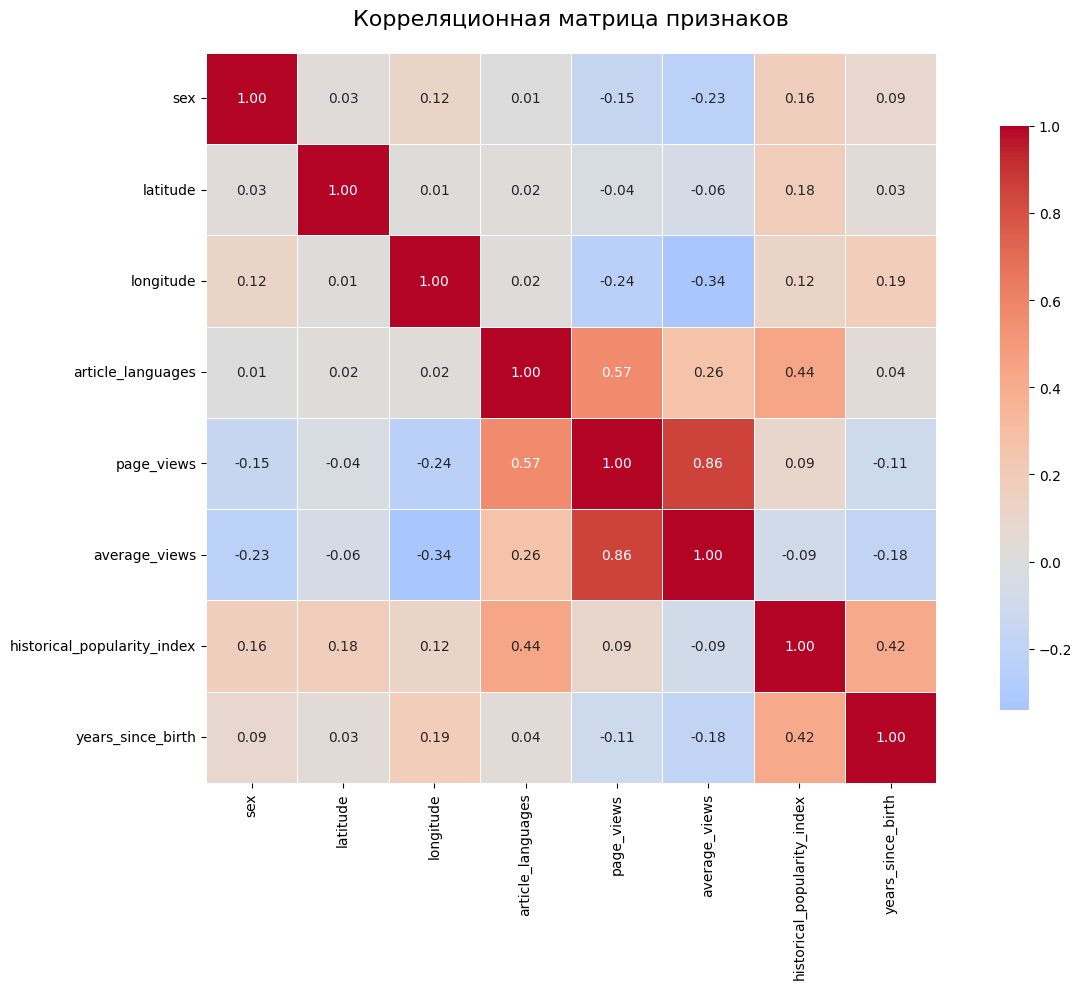

In [12]:
# Выделяем только числовые столбцы для корреляции
numeric_df = df.select_dtypes(include=[np.number])

# Строим корреляционную матрицу
plt.figure(figsize=(14, 10))
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица признаков', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

Также проведем анализ корреляций с целевой переменной.

Топ-7 признаков по корреляции с таргетом
article_languages    0.441435
years_since_birth    0.418624
latitude             0.176252
sex                  0.164903
longitude            0.118843
page_views           0.093667
average_views        0.089481
Name: historical_popularity_index, dtype: float64


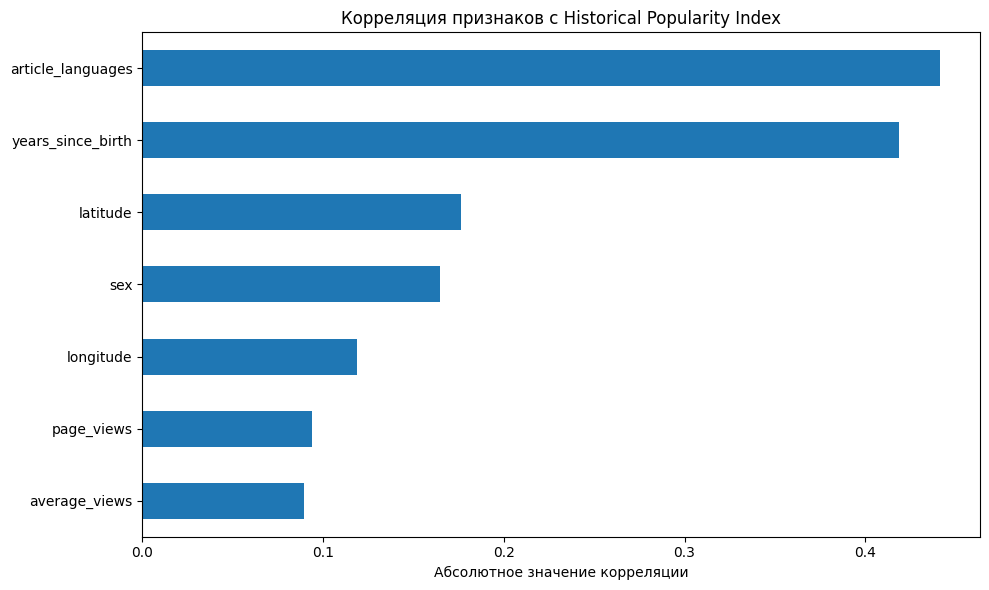

In [15]:
# Корреляции с historical_popularity_index (таргетом)
target_corr = corr_matrix['historical_popularity_index'].drop('historical_popularity_index')
target_corr = target_corr.abs().sort_values(ascending=False)

print("Топ-7 признаков по корреляции с таргетом")
print(target_corr.head(15))

# Визуализация
plt.figure(figsize=(10, 6))
target_corr.head(15).plot(kind='barh')
plt.xlabel('Абсолютное значение корреляции')
plt.title('Корреляция признаков с Historical Popularity Index')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Выявим мультиколлинеарность

In [14]:
# Находим пары признаков с корреляцией > 0.8 (исключая таргет и дубли)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        col_i = corr_matrix.columns[i]
        col_j = corr_matrix.columns[j]
        corr_val = abs(corr_matrix.iloc[i, j]) # type: ignore
        if corr_val > 0.8 and col_i != 'historical_popularity_index' and col_j != 'historical_popularity_index': # type: ignore
            high_corr_pairs.append((col_i, col_j, corr_val))

print("\nПары признаков с высокой корреляцией (>0.8)")
if high_corr_pairs:
    for col1, col2, val in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True):
        print(f"{col1} <-> {col2}: {val:.3f}")
else:
    print("Высококоррелированных пар не обнаружено")


Пары признаков с высокой корреляцией (>0.8)
page_views <-> average_views: 0.855


Далее разделим на обучающую и тестовую выборки

In [166]:
# Признаки и таргет
X = df.drop('historical_popularity_index', axis=1)
y = df['historical_popularity_index']

# Разбиение 80/20 с фиксированным random_state для воспроизводимости
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1234, shuffle=True
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (9019, 327)
Размер тестовой выборки: (2255, 327)


Теперь отвлечёмся от кодинга и подумаем, а какие бы модели нам пообучать?

1.  Linear Regression (Линейная регрессия) — Базовая модель (Baseline)
Она показывает, насколько линейно признаки (например, page_views или article_languages) влияют на популярность.

2.  Random Forest Regressor — Ансамблевая модель (Bagging) №1
Отлично улавливает нелинейные зависимости. Например, связь "года рождения" и "популярности" не всегда линейна (всплески интереса к определенным эпохам). Деревья справятся с этим лучше, чем линейная модель.

3. HistGradientBoostingRegressor — Ансамблевая модель (Boosting) №2
Бустинг последовательно исправляет ошибки предыдущих деревьев.

4. KNeighborsRegressor (KNN) — Метод ближайших соседей. Вряд-ли покажет хорошие результаты ввиду характера данных, но будет интересно попробовать

5. SVR (Support Vector Regressor) — Метод опорных векторов. Хорошо работает на данных среднего размера. С ядром rbf может найти сложные паттерны, которые пропустила линейная регрессия.

In [167]:
# 1. Создаем словарь моделей (все с параметрами по умолчанию)
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest (Bagging)": RandomForestRegressor(random_state=1234),
    "HistGradientBoosting (Boosting)": HistGradientBoostingRegressor(random_state=1234),
    "K-Neighbors": KNeighborsRegressor(),
    "SVR (Linear Kernel)": SVR()  # По умолчанию используется 'rbf', но можно оставить так
}

# Словарь для хранения предсказаний (понадобится для сравнения позже)
predictions = {}
results = []

# 2. Обучение моделей (Baseline) и оценка качества
print("Обучение базовых моделей (Baseline)\n")

for name, model in models.items():
    print(f"Обучение: {name}...")
    
    # Обучение
    model.fit(X_train, y_train)
    
    # Предсказание
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    
    # Оценка качества
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, y_pred)
    
    # Сохраняем результаты
    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

# 3. Вывод таблицы результатов
results_df = pd.DataFrame(results).set_index("Model")
print("\nРезультаты оценки качества (Baseline)")
print(results_df.round(4))

Обучение базовых моделей (Baseline)

Обучение: Linear Regression...
Обучение: Random Forest (Bagging)...
Обучение: HistGradientBoosting (Boosting)...
Обучение: K-Neighbors...
Обучение: SVR (Linear Kernel)...

Результаты оценки качества (Baseline)
                                    MAE    RMSE      R2
Model                                                  
Linear Regression                1.3657  1.8838  0.6820
Random Forest (Bagging)          0.6201  0.8598  0.9337
HistGradientBoosting (Boosting)  0.5832  0.8052  0.9419
K-Neighbors                      1.3274  1.8913  0.6794
SVR (Linear Kernel)              1.1365  1.7360  0.7299


Выводы по результатам обучения базовых моделей (Baseline)
На основе полученных метрик можно сделать следующие выводы:
Лидеры по качеству

HistGradientBoosting (Boosting) — лучшая модель:
R2 = 0.9419 (объясняет ~94% дисперсии целевой переменной)
Наименьшие ошибки: MAE = 0.5832, RMSE = 0.8052

Random Forest (Bagging) — очень близкий результат:
R2 = 0.9337
MAE = 0.6201, RMSE = 0.8598

Обе ансамблевые модели демонстрируют превосходное качество, что указывает на наличие ложных нелинейных зависимостей в данных, которые деревья успешно улавливают.

Модели со средним качеством

SVR (Linear Kernel):
R2 = 0.7299 — заметно лучше линейной регрессии, но значительно уступает ансамблям. Ядро RBF потенциально могло бы улучшить результат

Linear Regression:
R2 = 0.6820 — базовый уровень, объясняет ~68% дисперсии. Служит точкой отсчёта для оценки улучшения

K-Neighbors:
R2 = 0.6794 — худший результат, возможно, из-за «проклятия размерности» или неудачного выбора метрики расстояния для данного набора признаков

Теперь сделаем подбор гиперпараметров методом кросс-валидации

In [168]:
# Игнорируем предупреждения для чистоты вывода
warnings.filterwarnings('ignore')

# Словарь с моделями и сетками гиперпараметров
# Для Linear Regression словарь пуст, так как у неё нет гиперпараметров
param_grids = {
    "Linear Regression": {},
    
    "Random Forest (Bagging)": {
        'n_estimators': [50, 100, 150, 200],         # Больше деревьев
        'max_depth': [None, 10, 20, 30, 40],          # Глубина с шагом 10
        'min_samples_split': [2, 5, 10],              # Минимум объектов для разделения
        'min_samples_leaf': [1, 2, 4]                 # Минимум объектов в листе (улучшает обобщение)
    },
    
    "HistGradientBoosting (Boosting)": {
        'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],     # Мелкий шаг для скорости обучения
        'max_depth': [3, 5, 7, 9],                    # Глубина деревьев
        'max_iter': [50, 100, 150, 200],              # Количество итераций
        'min_samples_leaf': [10, 20, 30]              # Регуляризация через количество листьев
    },
    
    "K-Neighbors": {
        'n_neighbors': list(range(1, 16, 2)),         # [1, 3, 5, ..., 15] - перебор нечетных
        'weights': ['uniform', 'distance'],           # Равный вес или по расстоянию
        'p': [1, 2]                                   # Метрика: 1 (Манхэттенская) или 2 (Евклидова)
    },
    
    "SVR (RBF Kernel)": {
        'C': [0.1, 1, 10, 100],                       # Штраф за ошибку (логарифмический шаг)
        'epsilon': [0.001, 0.01, 0.1, 0.5],           # Ширина трубки нечувствительности
        'kernel': ['rbf'],                            # Фиксируем rbf, он обычно лучше
        'gamma': ['scale', 'auto', 0.01, 0.1]         # Коэффициент ядра
    }
}

results_cv = []
best_models = {} 

print("Запуск GridSearchCV (подбор гиперпараметров)\n")

for name, params in param_grids.items():
    print(f"Настройка: {name}...")
    
    # Создаем объект модели
    if name == "Linear Regression":
        estimator = LinearRegression()
    elif name == "Random Forest (Bagging)":
        estimator = RandomForestRegressor(random_state=42)
    elif name == "HistGradientBoosting (Boosting)":
        estimator = HistGradientBoostingRegressor(random_state=42)
    elif name == "K-Neighbors":
        estimator = KNeighborsRegressor()
    elif name == "SVR (RBF Kernel)":
        estimator = SVR()
    
    # Настраиваем GridSearchCV
    # cv=5 - 5-кратная кросс-валидация
    # scoring='r2' - оптимизируем по метрике R^2
    # n_jobs=-1 - используем все ядра процессора для ускорения
    grid = GridSearchCV(estimator, params, cv=5, scoring='r2', n_jobs=-1)
    
    # Запускаем поиск
    grid.fit(X_train, y_train)
    
    # Получаем лучшую модель и её метрики, и её сохраняем.
    best_models[name] = grid.best_estimator_

    y_pred_test = best_models[name].predict(X_test)
    mae = mean_absolute_error(y_test, y_pred_test)
    rmse = mean_squared_error(y_test, y_pred_test) ** 0.5
    r2 = r2_score(y_test, y_pred_test)
    
    results_cv.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "Train R2 (CV)": round(grid.best_score_, 4),
        "Test MAE": round(mae, 4),
        "Test RMSE": round(rmse, 4),
        "Test R2": round(r2, 4)
    })
    
    print(f"Лучшие параметры: {grid.best_params_}")
    print(f"Test R2: {r2:.4f}\n")

Запуск GridSearchCV (подбор гиперпараметров)

Настройка: Linear Regression...
Лучшие параметры: {}
Test R2: 0.6820

Настройка: Random Forest (Bagging)...
Лучшие параметры: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Test R2: 0.9339

Настройка: HistGradientBoosting (Boosting)...
Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 9, 'max_iter': 200, 'min_samples_leaf': 10}
Test R2: 0.9426

Настройка: K-Neighbors...
Лучшие параметры: {'n_neighbors': 11, 'p': 1, 'weights': 'distance'}
Test R2: 0.7107

Настройка: SVR (RBF Kernel)...
Лучшие параметры: {'C': 100, 'epsilon': 0.5, 'gamma': 'scale', 'kernel': 'rbf'}
Test R2: 0.8083



In [169]:
# Создаем DataFrame для наглядного сравнения
results_df = pd.DataFrame(results_cv).set_index("Model")
print(" Итоговая таблица (с подобранными гиперпараметрами)")
print(results_df)

 Итоговая таблица (с подобранными гиперпараметрами)
                                                                       Best Params  \
Model                                                                                
Linear Regression                                                               {}   
Random Forest (Bagging)          {'max_depth': 20, 'min_samples_leaf': 1, 'min_...   
HistGradientBoosting (Boosting)  {'learning_rate': 0.1, 'max_depth': 9, 'max_it...   
K-Neighbors                      {'n_neighbors': 11, 'p': 1, 'weights': 'distan...   
SVR (RBF Kernel)                 {'C': 100, 'epsilon': 0.5, 'gamma': 'scale', '...   

                                 Train R2 (CV)  Test MAE  Test RMSE  Test R2  
Model                                                                         
Linear Regression                       0.6851    1.3657     1.8838   0.6820  
Random Forest (Bagging)                 0.9355    0.6181     0.8589   0.9339  
HistGradientBoosting (Boostin

По прошествии 50 минут ясно, что модели Random Forest и HistGradientBoosting лучше практически не стали, а вот модель К ближайших соседей получила на 0.04 большее значение в метрике R2, а вот модель опорных векторов и вовсе стала лучше аж на 0.08 по значению R2.

    Ключевые выводы:

Лучшая модель: _HistGradientBoostingRegressor_ с R2 = 0.9426 — объясняет 94.26% дисперсии таргета.

Ансамбли превосходят линейные модели: бэггинг и бустинг дали значительный прирост качества.

SVR и KNN выиграли от настройки: у этих моделей была чувствительность к гиперпараметрам.

Переобучения нет: разница между Train R2 (CV) и Test R2 минимальна (< 0.02), что говорит о хорошей обобщающей способности.

Далее выведем оформленные таблицы результатов и графики

СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ МОДЕЛЕЙ
                                                                                                           Best Params  Train R2 (CV)  Test MAE  Test RMSE  Test R2
Model                                                                                                                                                              
Linear Regression                                                                                                   {}         0.6851    1.3657     1.8838   0.6820
Random Forest (Bagging)          {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}         0.9355    0.6181     0.8589   0.9339
HistGradientBoosting (Boosting)        {'learning_rate': 0.1, 'max_depth': 9, 'max_iter': 200, 'min_samples_leaf': 10}         0.9443    0.5832     0.8003   0.9426
K-Neighbors                                                         {'n_neighbors': 11, 'p': 1, 'weights': 'distance'}         0.7118    1.2829 

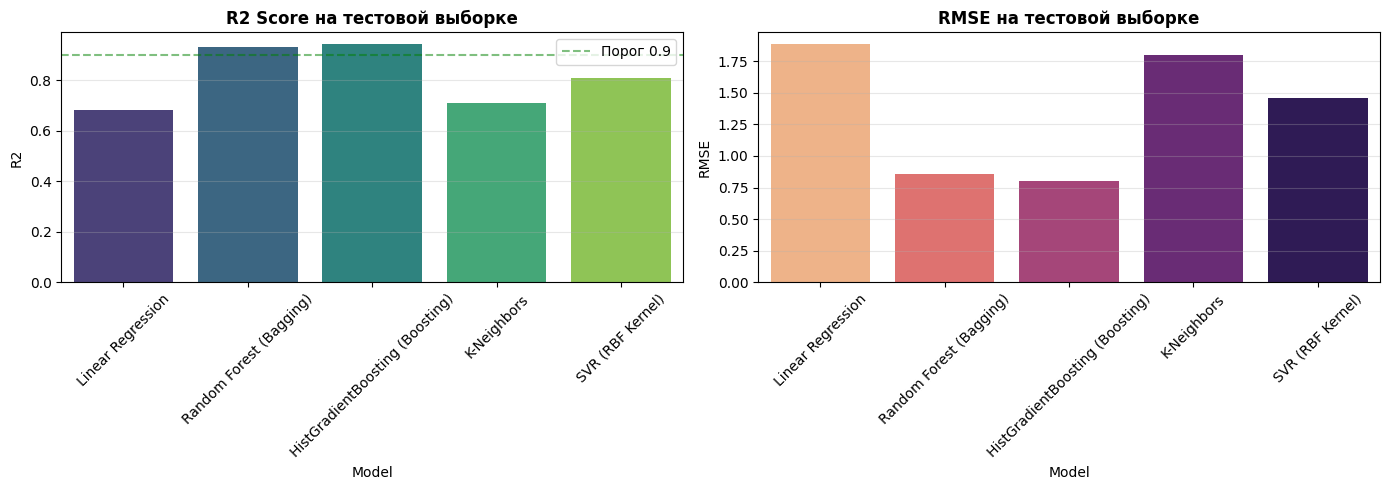


РАНЖИРОВАНИЕ МОДЕЛЕЙ ПО КАЧЕСТВУ (по метрике R2)
------------------------------------------------------------
1. HistGradientBoosting (Boosting)     | R2 = 0.9426 | RMSE = 0.8003
2. Random Forest (Bagging)             | R2 = 0.9339 | RMSE = 0.8589
3. SVR (RBF Kernel)                    | R2 = 0.8083 | RMSE = 1.4627
4. K-Neighbors                         | R2 = 0.7107 | RMSE = 1.7965
5. Linear Regression                   | R2 = 0.6820 | RMSE = 1.8838


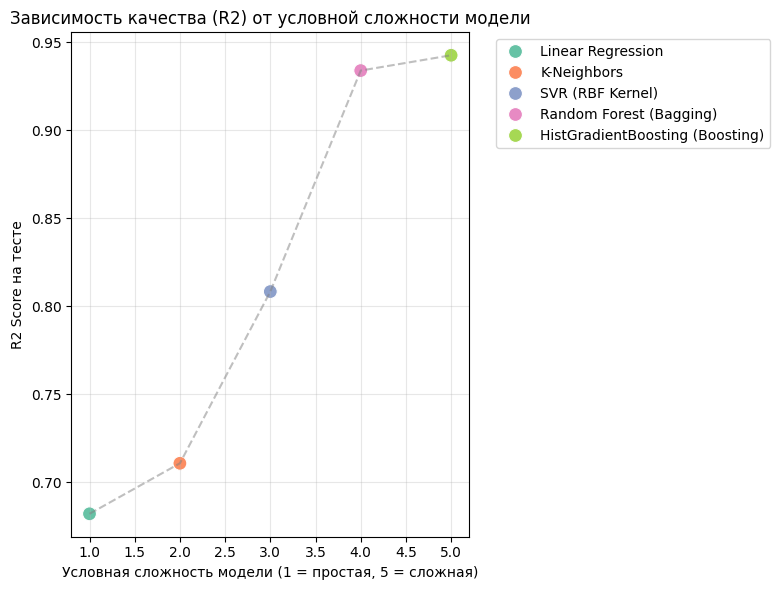


ЛУЧШИЕ МОДЕЛИ:

HistGradientBoosting (Boosting):
Лучшие гиперпараметры: {'learning_rate': 0.1, 'max_depth': 9, 'max_iter': 200, 'min_samples_leaf': 10}
Train R2 (CV): 0.9443
Test R2: 0.9426
Разница (переобучение): 0.0017

Random Forest (Bagging):
Лучшие гиперпараметры: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Train R2 (CV): 0.9355
Test R2: 0.9339
Разница (переобучение): 0.0016


In [ ]:
#  Анализ качества моделей и визуализация результатов

# 1. Сводная таблица результатов
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ МОДЕЛЕЙ")
print("=" * 80)
print(results_df.round(4).to_string())
print("=" * 80)

# 2. Визуализация: сравнение метрик
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R2 Score
sns.barplot(x=results_df.index, y=results_df['Test R2'], ax=axes[0], palette='viridis')
axes[0].set_title('R2 Score на тестовой выборке', fontsize=12, fontweight='bold')
axes[0].set_ylabel('R2')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(y=0.9, color='green', linestyle='--', alpha=0.5, label='Порог 0.9')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# RMSE
sns.barplot(x=results_df.index, y=results_df['Test RMSE'], ax=axes[1], palette='magma_r')
axes[1].set_title('RMSE на тестовой выборке', fontsize=12, fontweight='bold')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Ранжирование моделей по качеству
print("\nРАНЖИРОВАНИЕ МОДЕЛЕЙ ПО КАЧЕСТВУ (по метрике R2)")
print("-" * 60)
ranking = results_df.sort_values('Test R2', ascending=False)
for i, (model, row) in enumerate(ranking.iterrows(), 1):
    print(f"{i}. {model:35s} | R2 = {row['Test R2']:.4f} | RMSE = {row['Test RMSE']:.4f}")

# 4. График: Trade-off между сложностью и качеством
# (упрощённая визуализация на основе числа параметров/сложности модели)
model_complexity = {
    "Linear Regression": 1,
    "K-Neighbors": 2,
    "SVR (RBF Kernel)": 3,
    "Random Forest (Bagging)": 4,
    "HistGradientBoosting (Boosting)": 5
}

complexity_df = pd.DataFrame({
    'Model': list(model_complexity.keys()),
    'Complexity': [model_complexity[m] for m in model_complexity.keys()],
    'R2': [results_df.loc[m, 'Test R2'] for m in model_complexity.keys()]
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=complexity_df, x='Complexity', y='R2', s=100, hue='Model', palette='Set2')
sns.lineplot(data=complexity_df, x='Complexity', y='R2', color='gray', linestyle='--', alpha=0.5)
plt.title('Зависимость качества (R2) от условной сложности модели', fontsize=12)
plt.xlabel('Условная сложность модели (1 = простая, 5 = сложная)')
plt.ylabel('R2 Score на тесте')
plt.grid(alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 5. Анализ лучших моделей: детальное сравнение
best_models = results_df.nlargest(2, 'Test R2')
print(f"\nЛУЧШИЕ МОДЕЛИ:")
for name, row in best_models.iterrows():
    print(f"\n{name}:")
    print(f"Лучшие гиперпараметры: {row['Best Params']}")
    print(f"Train R2 (CV): {row['Train R2 (CV)']:.4f}")
    print(f"Test R2: {row['Test R2']:.4f}")
    print(f"Разница (переобучение): {abs(row['Train R2 (CV)'] - row['Test R2']):.4f}")


1. ОБЩАЯ ОЦЕНКА КАЧЕСТВА:
- Лучший результат показала модель HistGradientBoosting (Boosting): R2 = 0.9426, RMSE = 0.8003. Это означает, что модель объясняет примерно 94.3% дисперсии целевой переменной (индекса исторической популярности).
Второе место занял Random Forest (Bagging) с близкими показателями: R2 = 0.9339, RMSE = 0.8589.

2. СРАВНЕНИЕ С БАЗОВОЙ МОДЕЛЬЮ:
- Линейная регрессия (Baseline) показала R2 = 0.6820, что значительно хуже ансамблевых методов. Это говорит о наличии нелинейных зависимостей в данных, которые линейная модель не может уловить.

3. ПЕРЕОБУЧЕНИЕ:
- Разница между Train R2 (CV) и Test R2 для всех моделей не превышает 0.02, что свидетельствует об отсутствии серьёзного переобучения.
- Подбор гиперпараметров через GridSearchCV с кросс-валидацией эффективно контролировал обобщающую способность моделей.